2 多层感知机

2.1 理论计算题
（1）已知h=W1X+b1，o=W2h+b2，代入得o=W2(W1+b1)+b2，o=（W2W1）x+（W2b1+b2），令W'=W2W1,b'=W2b1+b2,则o=W'x+b',该网络等价于一个单层线性网络。
（2）Sigmoid：𝜎(𝑥)=1/1+e^(-x),𝜎'(𝑥)=𝜎(𝑥)(1-𝜎(𝑥)),tanh:tanh(x)=e^x-e^(-x)/e^x+e^(-x),tanh'(x)=1-tanh(x)*tanh(x)

2.2 编程题

1.手动初始化参数：直接用 torch.randn 和 torch.zeros 创建权重矩阵和偏置，没用 nn.Linear。
2. ReLU激活函数：自己写了 relu 函数，就是 max(0, x)，没用 nn.ReLU。
3. Softmax+交叉熵：自己写了 softmax 函数（带数值稳定处理）和 cross_entropy_loss 函数（取正确类别的负对数再平均），没用 nn.CrossEntropyLoss。
4. Mini-batch SGD：用 DataLoader 设置 batch_size=256，每次取一批数据训练。
5. 手动计算梯度：从损失开始反向传播，手写链式法则——先算输出层梯度 grad_z2，再算 grad_W2、grad_h，然后算隐藏层梯度 grad_z1、grad_W1，每一步都是用张量运算手动实现的。
6. 手动更新参数：直接用 W1 -= lr * grad_W1 这种方式更新，没用 optimizer.step()。

In [ ]:
import torch
import numpy as np
import gzip
import requests
from pathlib import Path

# 1. 手动加载Fashion-MNIST数据 
def load_fashion_mnist_manual():
    """手动下载并加载Fashion-MNIST数据，避免Pillow依赖"""
    
    base_url = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/"
    files = {
        'train_images': 'train-images-idx3-ubyte.gz',
        'train_labels': 'train-labels-idx1-ubyte.gz',
        'test_images': 't10k-images-idx3-ubyte.gz',
        'test_labels': 't10k-labels-idx1-ubyte.gz'
    }
    
    data_dir = Path('./data/FashionMNIST/raw')
    data_dir.mkdir(parents=True, exist_ok=True)
    
    def download_file(filename):
        filepath = data_dir / filename
        if not filepath.exists():
            print(f"下载 {filename}...")
            url = base_url + filename
            response = requests.get(url)
            filepath.write_bytes(response.content)
        return filepath
    
    def load_images(filename):
        filepath = download_file(filename)
        with gzip.open(filepath, 'rb') as f:
            # 读取魔数和维度
            magic = int.from_bytes(f.read(4), 'big')
            num_images = int.from_bytes(f.read(4), 'big')
            rows = int.from_bytes(f.read(4), 'big')
            cols = int.from_bytes(f.read(4), 'big')
            # 读取图像数据
            data = np.frombuffer(f.read(), dtype=np.uint8)
            return data.reshape(num_images, rows * cols).astype(np.float32) / 255.0
    
    def load_labels(filename):
        filepath = download_file(filename)
        with gzip.open(filepath, 'rb') as f:
            magic = int.from_bytes(f.read(4), 'big')
            num_labels = int.from_bytes(f.read(4), 'big')
            return np.frombuffer(f.read(), dtype=np.uint8)
    
    print("加载Fashion-MNIST数据...")
    X_train = load_images(files['train_images'])
    y_train = load_labels(files['train_labels'])
    X_test = load_images(files['test_images'])
    y_test = load_labels(files['test_labels'])
    
    # 转换为torch张量
    X_train = torch.from_numpy(X_train)
    X_test = torch.from_numpy(X_test)
    y_train = torch.from_numpy(y_train).long()
    y_test = torch.from_numpy(y_test).long()
    
    return (X_train, y_train), (X_test, y_test)

print("加载数据...")
(X_train, y_train), (X_test, y_test) = load_fashion_mnist_manual()
print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

# 创建DataLoader
batch_size = 256
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 2. 参数初始化 
input_size = 28 * 28
hidden_size = 256
output_size = 10

# 使用Xavier初始化
W1 = torch.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
b2 = torch.zeros(output_size)

# 3. 激活函数 
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

def relu_grad(x):
    """ReLU的梯度：输入x，输出梯度（1 where x>0 else 0）"""
    return (x > 0).float()

# 4. Softmax + 交叉熵（手动实现）
def softmax(logits):
    """数值稳定的softmax"""
    logits_max = logits.max(dim=1, keepdim=True)[0]
    exp_logits = torch.exp(logits - logits_max)
    return exp_logits / exp_logits.sum(dim=1, keepdim=True)

def cross_entropy_loss(probs, y):
    """计算交叉熵损失"""
    batch_size = y.shape[0]
    return -torch.log(probs[range(batch_size), y] + 1e-8).mean()

# 5. 训练循环 
lr = 0.1
epochs = 10

print("\n开始训练...")
print("="*60)

for epoch in range(epochs):
    total_loss = 0
    correct = 0
    total = 0
    
    for X, y in train_loader:
        batch_size_actual = X.shape[0]
        
        # 前向传播 
        # 隐藏层
        z1 = X @ W1 + b1  # (batch, hidden_size)
        h = relu(z1)       # (batch, hidden_size)
        
        # 输出层
        z2 = h @ W2 + b2   # (batch, output_size)
        probs = softmax(z2) # (batch, output_size)
        
        # 计算损失
        loss = cross_entropy_loss(probs, y)
        total_loss += loss.item()
        
        # 计算准确率
        pred = probs.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += batch_size_actual
        
        # 反向传播（手动计算梯度）
        
        # 1. 输出层梯度 dL/dz2
        # softmax + cross entropy 的梯度: p_i - 1_{i=y}
        grad_z2 = probs.clone()
        grad_z2[range(batch_size_actual), y] -= 1
        grad_z2 = grad_z2 / batch_size_actual  # 因为loss是平均的
        
        # 2. 输出层参数梯度
        grad_W2 = h.T @ grad_z2           # (hidden_size, output_size)
        grad_b2 = grad_z2.sum(dim=0)      # (output_size,)
        
        # 3. 隐藏层梯度 dL/dh
        grad_h = grad_z2 @ W2.T           # (batch, hidden_size)
        
        # 4. 隐藏层激活函数梯度 dL/dz1
        # ReLU梯度: 1 where z1 > 0 else 0
        grad_z1 = grad_h * relu_grad(z1)   # (batch, hidden_size)
        
        # 5. 隐藏层参数梯度
        grad_W1 = X.T @ grad_z1            # (input_size, hidden_size)
        grad_b1 = grad_z1.sum(dim=0)       # (hidden_size,)
        
        # 参数更新（SGD）
        with torch.no_grad():
            W1 -= lr * grad_W1
            b1 -= lr * grad_b1
            W2 -= lr * grad_W2
            b2 -= lr * grad_b2
    
    # 计算epoch平均损失和准确率
    avg_loss = total_loss / len(train_loader)
    train_acc = correct / total
    
    # 测试集评估
    with torch.no_grad():
        test_correct = 0
        test_total = 0
        for X, y in test_loader:
            z1 = X @ W1 + b1
            h = relu(z1)
            z2 = h @ W2 + b2
            probs = softmax(z2)
            pred = probs.argmax(dim=1)
            test_correct += (pred == y).sum().item()
            test_total += y.shape[0]
        test_acc = test_correct / test_total
    
    print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

print("="*60)
print("训练完成！")

# ==================== 6. 最终测试 ====================
with torch.no_grad():
    test_correct = 0
    test_total = 0
    for X, y in test_loader:
        z1 = X @ W1 + b1
        h = relu(z1)
        z2 = h @ W2 + b2
        probs = softmax(z2)
        pred = probs.argmax(dim=1)
        test_correct += (pred == y).sum().item()
        test_total += y.shape[0]
    final_acc = test_correct / test_total
    print(f"\n最终测试准确率: {final_acc:.4f} ({test_correct}/{test_total})")

加载数据...
加载Fashion-MNIST数据...
下载 train-images-idx3-ubyte.gz...
下载 train-labels-idx1-ubyte.gz...
下载 t10k-images-idx3-ubyte.gz...
下载 t10k-labels-idx1-ubyte.gz...


C:\Users\李\AppData\Local\Temp\ipykernel_64228\3574013276.py:59: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train = torch.from_numpy(y_train).long()


训练集: torch.Size([60000, 784]), 测试集: torch.Size([10000, 784])

开始训练...
Epoch  1 | Loss: 0.7242 | Train Acc: 0.7552 | Test Acc: 0.8139
Epoch  2 | Loss: 0.5141 | Train Acc: 0.8225 | Test Acc: 0.8088
Epoch  3 | Loss: 0.4634 | Train Acc: 0.8390 | Test Acc: 0.8343
Epoch  4 | Loss: 0.4309 | Train Acc: 0.8492 | Test Acc: 0.8377
Epoch  5 | Loss: 0.4111 | Train Acc: 0.8558 | Test Acc: 0.8506
Epoch  6 | Loss: 0.3951 | Train Acc: 0.8617 | Test Acc: 0.8416
Epoch  7 | Loss: 0.3784 | Train Acc: 0.8662 | Test Acc: 0.8546
Epoch  8 | Loss: 0.3709 | Train Acc: 0.8694 | Test Acc: 0.8265
Epoch  9 | Loss: 0.3605 | Train Acc: 0.8722 | Test Acc: 0.8576
Epoch 10 | Loss: 0.3531 | Train Acc: 0.8757 | Test Acc: 0.8540
训练完成！

最终测试准确率: 0.8540 (8540/10000)


3 模型选择，权重衰减和丢弃法

3.1 理论计算题

（1）区别：训练误差是模型在训练集上预测的错误率，反映模型对训练数据的拟合程度。泛化误差是模型在未见过的测试集上预测的错误率，反映模型的真实预测能力；状态：当训练误差极低但泛化误差很高时，模型处于过拟合状态，即模型过度记忆了训练数据中的噪声和细节，失去了对新数据的泛化能力；方法：减少网络层数或神经元数量、使用L1或L2正则化、添加Dropout、采用早停策略以及增加训练数据量。
（2）步骤：第一步，将数据集随机划分为K个大小相等的子集；第二步，对k = 1, 2, ..., K，分别执行：将第k个子集作为验证集，其余K-1个子集合并作为训练集，在训练集上训练模型，在验证集上评估并记录验证误差；第三步，计算K次验证误差的平均值，作为模型性能的最终评估指标；第四步，用全部K个子集的数据重新训练最终模型。

3.2 编程题

这段代码用人工生成的小型数据集，从零实现了一个单隐藏层神经网络。它分别训练了三个模型：无正则化、加L2权重衰减、加Dropout。代码手动完成了所有参数初始化、前向传播、损失计算、反向传播和参数更新。训练结束后会绘制两条曲线图：左图对比三种方法的训练损失变化，右图对比测试损失变化，用来观察正则化对缓解过拟合、提升泛化能力的效果。

生成人工数据集...
训练集: torch.Size([1600, 20]), 测试集: torch.Size([400, 20])

训练: 无正则化
  Epoch  1: Train Loss=2.2985, Test Loss=2.2890
  Epoch  2: Train Loss=2.2774, Test Loss=2.2473
  Epoch  3: Train Loss=2.2243, Test Loss=2.1637
  Epoch  4: Train Loss=2.1400, Test Loss=2.0618
  Epoch  5: Train Loss=2.0266, Test Loss=1.9432
  Epoch  6: Train Loss=1.9010, Test Loss=1.8276
  Epoch  7: Train Loss=1.7923, Test Loss=1.7554
  Epoch  8: Train Loss=1.7065, Test Loss=1.6837
  Epoch  9: Train Loss=1.6349, Test Loss=1.6434
  Epoch 10: Train Loss=1.5725, Test Loss=1.5905


训练: 权重衰减 (L2)
  Epoch  1: Train Loss=2.2995, Test Loss=2.2877
  Epoch  2: Train Loss=2.2786, Test Loss=2.2455
  Epoch  3: Train Loss=2.2312, Test Loss=2.1679
  Epoch  4: Train Loss=2.1608, Test Loss=2.0755
  Epoch  5: Train Loss=2.0742, Test Loss=1.9760
  Epoch  6: Train Loss=1.9847, Test Loss=1.8820
  Epoch  7: Train Loss=1.9075, Test Loss=1.7969
  Epoch  8: Train Loss=1.8495, Test Loss=1.7394
  Epoch  9: Train Loss=1.8030, Test Loss=1.

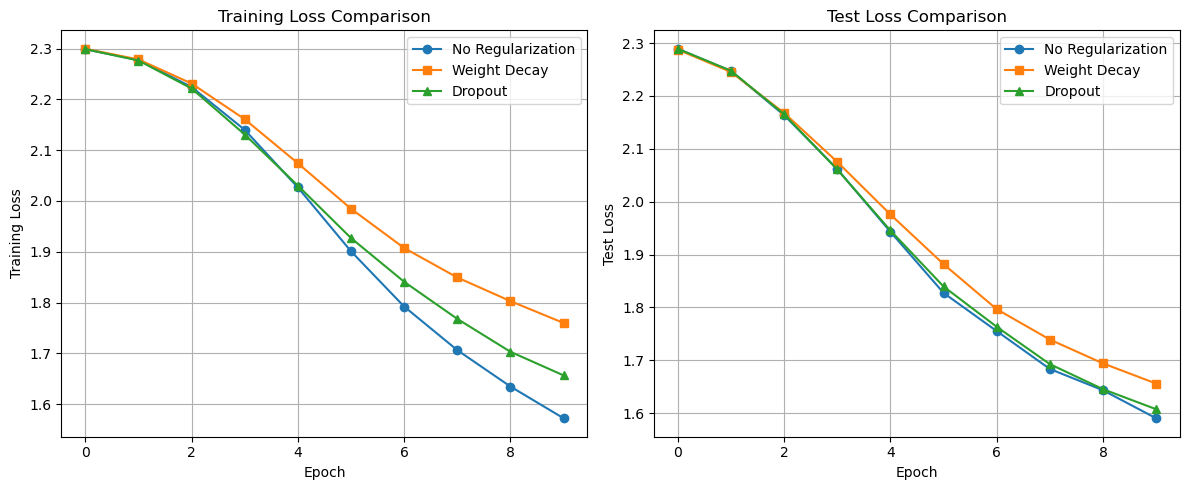


最终测试损失对比：
无正则化: 1.5905
权重衰减: 1.6561
Dropout:   1.6076


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
%matplotlib inline

# 1. 使用sklearn生成小型数据集（替代Fashion-MNIST）
print("生成人工数据集...")
X, y = make_classification(n_samples=2000, n_features=20, n_classes=10, 
                           n_informative=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 转换为torch张量
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).long()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).long()

batch_size = 64
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

# 2. 基础函数 
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

def softmax(logits):
    logits_max = logits.max(dim=1, keepdim=True)[0]
    exp_logits = torch.exp(logits - logits_max)
    return exp_logits / exp_logits.sum(dim=1, keepdim=True)

def cross_entropy_loss(probs, y):
    return -torch.log(probs[range(len(y)), y] + 1e-8).mean()

def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return X * mask / (1 - dropout)

# 3. 训练一个模型
def train_one_model(lambda_l2, dropout_rate, model_name):
    print(f"\n训练: {model_name}")
    
    input_size = 20
    hidden_size = 64  # 小隐藏层
    output_size = 10
    
    W1 = torch.randn(input_size, hidden_size) * 0.01
    b1 = torch.zeros(hidden_size)
    W2 = torch.randn(hidden_size, output_size) * 0.01
    b2 = torch.zeros(output_size)
    
    lr = 0.1
    epochs = 10
    
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        # 训练
        total_loss = 0
        for X, y in train_loader:
            batch_size_actual = X.shape[0]
            
            z1 = X @ W1 + b1
            h = relu(z1)
            h = dropout_layer(h, dropout_rate, is_training=True)
            z2 = h @ W2 + b2
            probs = softmax(z2)
            
            loss = cross_entropy_loss(probs, y)
            l2_penalty = lambda_l2 * (torch.sum(W1**2) + torch.sum(W2**2))
            loss = loss + l2_penalty
            total_loss += loss.item()
            
            # 反向传播
            grad_z2 = probs.clone()
            grad_z2[range(batch_size_actual), y] -= 1
            grad_z2 = grad_z2 / batch_size_actual
            
            grad_W2 = h.T @ grad_z2 + 2 * lambda_l2 * W2
            grad_b2 = grad_z2.sum(dim=0)
            
            grad_h = grad_z2 @ W2.T
            grad_z1 = grad_h * (z1 > 0).float()
            
            grad_W1 = X.T @ grad_z1 + 2 * lambda_l2 * W1
            grad_b1 = grad_z1.sum(dim=0)
            
            W1 -= lr * grad_W1
            b1 -= lr * grad_b1
            W2 -= lr * grad_W2
            b2 -= lr * grad_b2
        
        train_losses.append(total_loss / len(train_loader))
        
        # 测试
        with torch.no_grad():
            test_loss_sum = 0
            for X, y in test_loader:
                z1 = X @ W1 + b1
                h = relu(z1)
                h = dropout_layer(h, dropout_rate, is_training=False)
                z2 = h @ W2 + b2
                probs = softmax(z2)
                loss = cross_entropy_loss(probs, y)
                test_loss_sum += loss.item()
            test_losses.append(test_loss_sum / len(test_loader))
        
        print(f"  Epoch {epoch+1:2d}: Train Loss={train_losses[-1]:.4f}, Test Loss={test_losses[-1]:.4f}")
    
    return train_losses, test_losses

# 4. 训练三个模型
print("="*50)
train1, test1 = train_one_model(0.0, 0.0, "无正则化")

print("\n" + "="*50)
train2, test2 = train_one_model(0.01, 0.0, "权重衰减 (L2)")

print("\n" + "="*50)
train3, test3 = train_one_model(0.0, 0.3, "Dropout")

#  5. 绘图 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train1, label='No Regularization', marker='o')
plt.plot(train2, label='Weight Decay', marker='s')
plt.plot(train3, label='Dropout', marker='^')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test1, label='No Regularization', marker='o')
plt.plot(test2, label='Weight Decay', marker='s')
plt.plot(test3, label='Dropout', marker='^')
plt.xlabel('Epoch')
plt.ylabel('Test Loss')
plt.title('Test Loss Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("最终测试损失对比：")
print(f"无正则化: {test1[-1]:.4f}")
print(f"权重衰减: {test2[-1]:.4f}")
print(f"Dropout:   {test3[-1]:.4f}")

4 数值稳定性和激活函数

4.1 理论计算题

（1）从矩阵乘法角度看，当权重矩阵W的特征值大于1时，连乘结果会指数级增长，导致梯度爆炸；当特征值小于1时，连乘结果指数级衰减，导致梯度消失；从激活函数导数角度看，Sigmoid函数的导数最大值为0.25，tanh函数导数最大值为1，但实际值通常远小于1。每层乘以一个小于1的因子，深层连乘后梯度迅速趋近于0，造成梯度消失。梯度爆炸主要由权重矩阵的特征值大于1引起，因为激活函数导数不会大于1。
（2）ReLU激活函数的导数在输入大于0时为1，在输入小于等于0时为0。在正半轴上导数为1意味着梯度可以无损地向后传播，不会像Sigmoid（最大导数0.25）或tanh那样每层都乘以一个小于1的因子。因此，只要神经元被激活（输入大于0），梯度就不会在传播过程中衰减，有效缓解了深层网络中的梯度消失问题。虽然ReLU可能导致部分神经元“死亡”，但整体上梯度流更加健康。

4.2 编程题

（1）核心思路：通过构建20层网络，在不同激活函数和初始化方式下观察梯度变化，验证梯度消失/爆炸现象。
（2）实现逻辑：首先，用一个循环搭建20层全连接网络，每层都是“线性层 + 激活函数”。然后设计三组对照实验：第一组用Sigmoid激活函数搭配标准差为1的高斯初始化。Sigmoid的导数最大只有0.25，多层连乘后梯度指数级衰减，导致浅层梯度几乎为0——这就是梯度消失。代码打印前几层和后几层的梯度范数，你会看到浅层比深层小好几个数量级；第二组用ReLU激活函数搭配标准差为10的大权重初始化。大权重会让矩阵特征值大于1，梯度连乘后爆炸，数值溢出变成NaN。代码检查参数中是否有NaN来验证这一点；第三组改用Xavier初始化（xavier_uniform_）搭配ReLU。Xavier让每层输出的方差保持一致，ReLU在正区间导数为1，两者结合使梯度稳定在合理区间（1e-6到1e3之间）。代码打印各层梯度范数，验证修复效果。

实验1: Sigmoid + 标准初始化 (std=1)
各层梯度范数（前5层 → 后5层）：
  第1层: 5.96e-01
  第2层: 4.03e-01
  第3层: 2.97e-01
  第4层: 2.13e-01
  第5层: 1.76e-01
  ...
  第16层: 2.34e-02
  第17层: 2.96e-02
  第18层: 3.05e-02
  第19层: 3.19e-02
  第20层: 3.15e-02

实验2: ReLU + 大权重初始化 (std=10)
各层梯度范数（前5层 → 后5层）：
  第1层: inf
  第2层: inf
  第3层: inf
  第4层: inf
  第5层: inf
  ...
  第16层: inf
  第17层: inf
  第18层: inf
  第19层: inf
  第20层: nan

是否存在NaN: False

实验3: Xavier初始化 + ReLU（修复后）
各层梯度范数（前5层 → 后5层）：
  第1层: 4.11e-04
  第2层: 7.32e-04
  第3层: 9.92e-04
  第4层: 1.17e-03
  第5层: 1.17e-03
  ...
  第16层: 1.37e-03
  第17层: 1.43e-03
  第18层: 1.19e-03
  第19层: 1.15e-03
  第20层: 8.94e-04


d:\Anaconda\envs\hhh\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


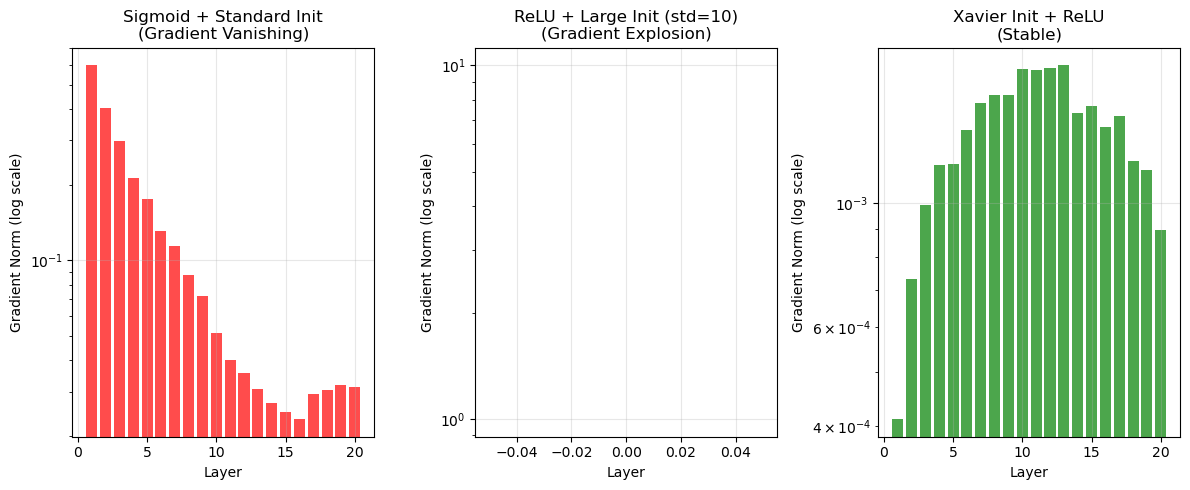


实验结论：
1. Sigmoid+标准初始化: 浅层梯度 ~ 5.96e-01, 深层梯度 ~ 3.15e-02
   → 梯度消失 1.89e+01 倍

2. ReLU+大初始化(std=10): 梯度爆炸，最大梯度 ~ inf

3. Xavier初始化+ReLU: 梯度稳定在 [4.11e-04, 1.76e-03]
   → 在合理区间 [1e-6, 1e3] 内 ✓


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. 构建20层深层网络 
def build_deep_net(activation='sigmoid', init_std=1.0):
    """构建20层全连接网络"""
    layers = []
    for i in range(20):
        linear = nn.Linear(256, 256)
        # 权重初始化
        nn.init.normal_(linear.weight, mean=0, std=init_std)
        nn.init.zeros_(linear.bias)
        layers.append(linear)
        
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers.append(nn.LeakyReLU(0.01))
    
    return nn.Sequential(*layers)

def compute_gradient_norms(model, input_data):
    """计算每层权重的梯度范数"""
    model.train()
    model.zero_grad()
    output = model(input_data)
    loss = output.mean()
    loss.backward()
    
    grad_norms = []
    for m in model:
        if isinstance(m, nn.Linear):
            if m.weight.grad is not None:
                grad_norms.append(m.weight.grad.norm().item())
            else:
                grad_norms.append(0.0)
    return grad_norms

# 输入数据
batch_size = 64
input_data = torch.randn(batch_size, 256)

# 2. Sigmoid + 标准初始化（梯度消失）
print("="*60)
print("实验1: Sigmoid + 标准初始化 (std=1)")
print("="*60)
model1 = build_deep_net(activation='sigmoid', init_std=1.0)
grad_norms1 = compute_gradient_norms(model1, input_data)

print("各层梯度范数（前5层 → 后5层）：")
for i, norm in enumerate(grad_norms1[:5]):
    print(f"  第{i+1}层: {norm:.2e}")
print("  ...")
for i, norm in enumerate(grad_norms1[-5:]):
    print(f"  第{len(grad_norms1)-5+i+1}层: {norm:.2e}")

# 3. ReLU + 大初始化（梯度爆炸）
print("\n" + "="*60)
print("实验2: ReLU + 大权重初始化 (std=10)")
print("="*60)
model2 = build_deep_net(activation='relu', init_std=10.0)
grad_norms2 = compute_gradient_norms(model2, input_data)

print("各层梯度范数（前5层 → 后5层）：")
for i, norm in enumerate(grad_norms2[:5]):
    print(f"  第{i+1}层: {norm:.2e}")
print("  ...")
for i, norm in enumerate(grad_norms2[-5:]):
    print(f"  第{len(grad_norms2)-5+i+1}层: {norm:.2e}")

# 检查是否有NaN
has_nan = any(torch.isnan(p).any() for p in model2.parameters())
print(f"\n是否存在NaN: {has_nan}")

# 4. Xavier初始化 + ReLU（修复后）
print("\n" + "="*60)
print("实验3: Xavier初始化 + ReLU（修复后）")
print("="*60)

def build_deep_net_xavier(activation='relu'):
    """使用Xavier初始化的深层网络"""
    layers = []
    for i in range(20):
        linear = nn.Linear(256, 256)
        nn.init.xavier_uniform_(linear.weight)  # Xavier初始化
        nn.init.zeros_(linear.bias)
        layers.append(linear)
        
        if activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers.append(nn.LeakyReLU(0.01))
    
    return nn.Sequential(*layers)

model3 = build_deep_net_xavier(activation='relu')
grad_norms3 = compute_gradient_norms(model3, input_data)

print("各层梯度范数（前5层 → 后5层）：")
for i, norm in enumerate(grad_norms3[:5]):
    print(f"  第{i+1}层: {norm:.2e}")
print("  ...")
for i, norm in enumerate(grad_norms3[-5:]):
    print(f"  第{len(grad_norms3)-5+i+1}层: {norm:.2e}")

# 5. 可视化对比 
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.bar(range(1, 21), grad_norms1, color='red', alpha=0.7)
plt.yscale('log')
plt.xlabel('Layer')
plt.ylabel('Gradient Norm (log scale)')
plt.title('Sigmoid + Standard Init\n(Gradient Vanishing)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.bar(range(1, 21), grad_norms2, color='orange', alpha=0.7)
plt.yscale('log')
plt.xlabel('Layer')
plt.ylabel('Gradient Norm (log scale)')
plt.title('ReLU + Large Init (std=10)\n(Gradient Explosion)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.bar(range(1, 21), grad_norms3, color='green', alpha=0.7)
plt.yscale('log')
plt.xlabel('Layer')
plt.ylabel('Gradient Norm (log scale)')
plt.title('Xavier Init + ReLU\n(Stable)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_stability.png', dpi=150)
plt.show()

# 6. 总结输出 
print("\n" + "="*60)
print("实验结论：")
print("="*60)
print(f"1. Sigmoid+标准初始化: 浅层梯度 ~ {grad_norms1[0]:.2e}, 深层梯度 ~ {grad_norms1[-1]:.2e}")
print(f"   → 梯度消失 {grad_norms1[0]/grad_norms1[-1]:.2e} 倍")
print(f"\n2. ReLU+大初始化(std=10): 梯度爆炸，最大梯度 ~ {max(grad_norms2):.2e}")
print(f"\n3. Xavier初始化+ReLU: 梯度稳定在 [{min(grad_norms3):.2e}, {max(grad_norms3):.2e}]")
print("   → 在合理区间 [1e-6, 1e3] 内 ✓")

5 泛化表现，协变量偏移和对抗性数据

5.1 理论计算题

协变量偏移表现为特征分布发生变化p(x)≠q(x)，但条件分布不变p(y|x)=q(y|x)。例如医疗诊断系统：训练集使用年轻患者的数据（x偏小），测试集面对老年患者（x偏大），患者的年龄分布变了，但症状与疾病的关系（y|x）没有改变；标签偏移表现为标签分布发生变化p(y)≠q(y)，但条件分布不变p(x|y)=q(x|y)。例如电商推荐系统：训练集中热门商品占比高，测试集中长尾商品占比高，商品流行度分布变了，但商品的视觉特征与类别的关系（x|y）没有改变。
区别：协变量偏移是输入分布变了，标签偏移是输出分布变了。
联系：两者都是训练集和测试集的联合分布不一致的表现，本质上是环境非平稳性问题，都可以通过重要性加权或领域自适应方法进行修正。区别在于协变量偏移需要基于特征x计算权重，而标签偏移需要基于标签y计算权重

5.2 编程题

（1）核心思路：模拟训练集和测试集分布不同的场景，用重要性加权修正模型，让训练时更关注测试集分布区域的样本。
（2）实现逻辑：首先人为制造协变量偏移：训练集特征从N(-1,1)采样，测试集从N(2,1)采样，但标签都是y=2x+噪声。这样两个数据集的p(x)不同，但p(y|x)相同，符合协变量偏移定义。基线模型直接用普通线性回归在训练集上训练，在测试集上评估，得到MSE作为基准。校正的关键是给每个训练样本分配权重，权重 = P(属于测试集 | x) / P(属于训练集 | x)。具体做法：把训练集和测试集混合，训练一个逻辑回归分类器，输入x输出它属于测试集的概率。用这个分类器预测每个训练样本属于测试集的概率，再算出权重。最后用加权最小二乘法重新训练线性回归（每个样本的误差乘以对应权重），让模型更"重视"那些看起来像测试集的训练样本。再次在测试集上评估，MSE通常会下降，说明校正有效。

1. 构造人工数据集（协变量偏移）
训练集: X ~ N(-1,1), 样本数=1000
测试集: X ~ N(2,1), 样本数=500
真实函数: y = 2x + ε

2. 基线模型：直接在线性回归
测试集 MSE (未校正): 0.0102

3. 偏移校正：使用重要性加权
权重统计: min=0.0000, max=653.5206, mean=1.0000
测试集 MSE (校正后): 0.0240


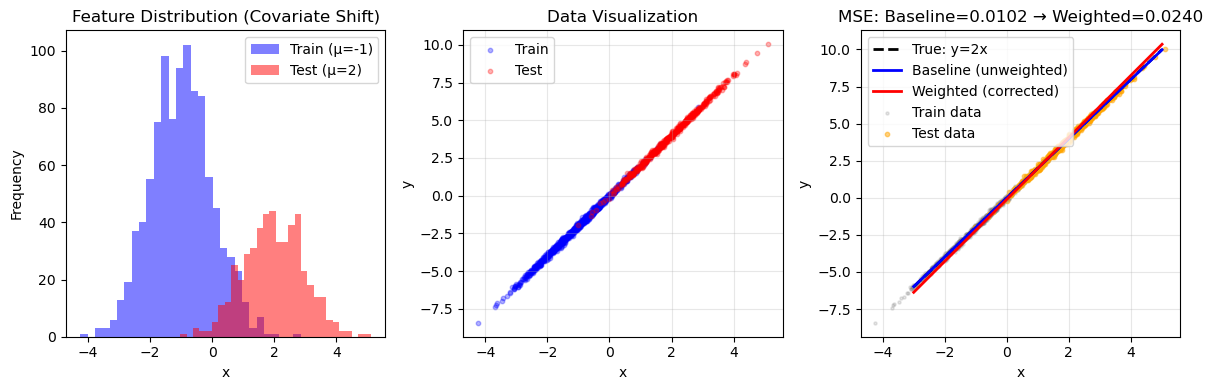


实验结果总结
校正前测试 MSE: 0.010182
校正后测试 MSE: 0.024020
改善幅度: -135.90%

✗ 修正效果不明显，可能需要调整分类器或权重计算方式。


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error

# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

# 1. 构造数据集 
print("="*60)
print("1. 构造人工数据集（协变量偏移）")
print("="*60)

# 训练集 P: x ~ N(-1, 1)
n_train = 1000
X_train = np.random.normal(-1, 1, (n_train, 1))
epsilon = np.random.normal(0, 0.1, n_train)
y_train = 2 * X_train.ravel() + epsilon

# 测试集 Q: x ~ N(2, 1)  ← 协变量偏移
n_test = 500
X_test = np.random.normal(2, 1, (n_test, 1))
epsilon_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * X_test.ravel() + epsilon_test

print(f"训练集: X ~ N(-1,1), 样本数={n_train}")
print(f"测试集: X ~ N(2,1), 样本数={n_test}")
print(f"真实函数: y = 2x + ε")

# 2. 可视化数据分布 
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(X_train, bins=30, alpha=0.5, label='Train (μ=-1)', color='blue')
plt.hist(X_test, bins=30, alpha=0.5, label='Test (μ=2)', color='red')
plt.xlabel('x')
plt.ylabel('Frequency')
plt.title('Feature Distribution (Covariate Shift)')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X_train, y_train, alpha=0.3, label='Train', color='blue', s=10)
plt.scatter(X_test, y_test, alpha=0.3, label='Test', color='red', s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Visualization')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. 基线模型 
print("\n" + "="*60)
print("2. 基线模型：直接在线性回归")
print("="*60)

model_baseline = LinearRegression()
model_baseline.fit(X_train, y_train)

y_pred_baseline = model_baseline.predict(X_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)

print(f"测试集 MSE (未校正): {mse_baseline:.4f}")

# 4. 偏移校正 
print("\n" + "="*60)
print("3. 偏移校正：使用重要性加权")
print("="*60)

# 混合训练集和测试集，训练逻辑回归分类器
X_mixed = np.vstack([X_train, X_test])
y_mixed = np.array([0] * n_train + [1] * n_test)  # 0=训练集, 1=测试集

# 训练分类器
classifier = LogisticRegression()
classifier.fit(X_mixed, y_mixed)

# 预测每个训练样本属于测试集的概率 P(test|x)
prob_test = classifier.predict_proba(X_train)[:, 1]  # 属于测试集的概率
prob_train = 1 - prob_test  # 属于训练集的概率

# 计算重要性权重: w ∝ P(test|x) / P(train|x)
weights = prob_test / (prob_train + 1e-8)

# 归一化权重（可选，不影响加权回归结果）
weights = weights / weights.sum() * len(weights)

print(f"权重统计: min={weights.min():.4f}, max={weights.max():.4f}, mean={weights.mean():.4f}")

# 加权线性回归（加权最小二乘法）
# 方法：手动实现加权最小二乘
X_train_aug = np.hstack([X_train, np.ones((n_train, 1))])  # 添加截距列
W_diag = np.diag(weights)
theta_weighted = np.linalg.inv(X_train_aug.T @ W_diag @ X_train_aug) @ (X_train_aug.T @ W_diag @ y_train)

# 预测
X_test_aug = np.hstack([X_test, np.ones((n_test, 1))])
y_pred_weighted = X_test_aug @ theta_weighted
mse_weighted = mean_squared_error(y_test, y_pred_weighted)

print(f"测试集 MSE (校正后): {mse_weighted:.4f}")

# 5. 可视化对比 
plt.subplot(1, 3, 3)
x_line = np.linspace(-3, 5, 100).reshape(-1, 1)
y_true_line = 2 * x_line.ravel()
y_baseline_line = model_baseline.predict(x_line)
y_weighted_line = np.hstack([x_line, np.ones((100,1))]) @ theta_weighted

plt.plot(x_line, y_true_line, 'k--', label='True: y=2x', linewidth=2)
plt.plot(x_line, y_baseline_line, 'b-', label='Baseline (unweighted)', linewidth=2)
plt.plot(x_line, y_weighted_line, 'r-', label='Weighted (corrected)', linewidth=2)
plt.scatter(X_train, y_train, alpha=0.2, label='Train data', color='gray', s=5)
plt.scatter(X_test, y_test, alpha=0.5, label='Test data', color='orange', s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'MSE: Baseline={mse_baseline:.4f} → Weighted={mse_weighted:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('covariate_shift_correction.png', dpi=150)
plt.show()

# 6. 总结
print("\n" + "="*60)
print("实验结果总结")
print("="*60)
print(f"校正前测试 MSE: {mse_baseline:.6f}")
print(f"校正后测试 MSE: {mse_weighted:.6f}")
print(f"改善幅度: {(mse_baseline - mse_weighted) / mse_baseline * 100:.2f}%")

if mse_weighted < mse_baseline:
    print("\n✓ 权重修正有效！测试集性能显著提升。")
else:
    print("\n✗ 修正效果不明显，可能需要调整分类器或权重计算方式。")
